# Point Defect Model

Many intermetallic compounds are stable over a range of compositions because atoms can swap between
sublattices or leave vacancies behind.  In the CALPHAD community this is captured by the
**Compound Energy Formalism (CEF)**, where each sublattice carries its own site-fraction variables
and the Gibbs energy is expanded over all "endmember" configurations.  `landau` provides an
equivalent but physically transparent formulation derived directly from the **semi-grand canonical
partition function**, making it straightforward to connect first-principles point-defect calculations
to thermodynamic phase diagrams.

## Theory

### Crystal model

Consider a crystalline phase whose primitive unit cell is partitioned into $L$ crystallographic
sublattices.  Sublattice $l$ contains $n_l$ sites per unit cell; the fraction of all atomic sites
belonging to sublattice $l$ is

$$\eta_l = \frac{n_l}{\sum_{l'} n_{l'}}.$$

For a **binary A–B alloy** each site on sublattice $l$ can be in three states: occupied by the
host species, occupied by an antisite, or vacant.

### Excess semi-grand potential of a defect

The **excess semi-grand potential** of a single point defect relative to the same volume of
perfect host crystal is

$$[\phi_i^l] = [g_i^l] - \Delta\mu\,[n_i^l],$$

where $[g_i^l] = E_i^l - T S_i^l$ is the defect formation free energy, $[n_i^l]$ is the excess
number of B-type solute atoms contributed by defect $i$ on sublattice $l$, and
$\Delta\mu = \mu_B - \mu_A$ is the semi-grand chemical potential.

### Semi-grand partition function

Because defects on different sublattices are independent, the partition function factorises.
The **total semi-grand potential per atom** of the defected phase is

$$\boxed{\phi(\beta, \Delta\mu) = \phi_\text{host}(\beta, \Delta\mu)
  - \frac{1}{\beta} \sum_l \eta_l
    \ln\!\left(1 + \sum_i e^{-\beta[\phi_i^l]}\right)} \tag{1}$$

The corresponding **concentration** follows from $c = -\partial\phi/\partial(\Delta\mu)$:

$$c(\beta, \Delta\mu) = c_\text{host}
  + \sum_l \eta_l \sum_i [n_i^l]\, x_i^l(\beta, \Delta\mu) \tag{2}$$

with the **defect site fraction** (softmax over all states of a sublattice site)

$$x_i^l = \frac{e^{-\beta[\phi_i^l]}}{1 + \sum_{i'} e^{-\beta[\phi_{i'}^l]}}. \tag{3}$$

The denominator captures **site competition**: a sublattice site can only be in one state at a
time, so $\sum_i x_i^l \le 1$ and concentrations are always physically bounded.

### Connection to the Compound Energy Formalism

Equation (1) is equivalent to the CEF at the level of ideal mixing, with the identifications:

- Endmember energies $G_{s_1:s_2:\cdots}$ $\leftrightarrow$ combinations of
  $\phi_\text{host}$ and defect formation energies $E_i^l$.
- Site fractions $y_s^l$ $\leftrightarrow$ defect site fractions $x_i^l$ (Eq. 3).

The practical difference: the CEF parametrises **endmember energies** (which can be hard to
access for unstable endmembers), while the point defect model parametrises **individual defect
formation energies** — the natural output of DFT supercell calculations.

## Prelude

In [1]:
from landau.phases import (
    LinePhase,
    IdealSolution,
    ConstantPointDefect,
    PointDefectSublattice,
    PointDefectedPhase,
)
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram

In [2]:
import numpy as np
from scipy.constants import Boltzmann, eV
kB = Boltzmann / eV

In [3]:
import matplotlib.pyplot as plt

## Python API

Four classes implement Eqs. (1)–(3):

| Class | Role |
|-------|------|
| `ConstantPointDefect` | Single defect with constant formation energy $E_i^l$ and entropy $S_i^l$ |
| `PointDefectSublattice` | All defects on one sublattice; computes Eq. (1) per sublattice |
| `PointDefectedPhase` | Full phase = host `AbstractLinePhase` + list of `PointDefectSublattice` |

All point defect classes are in `landau.phases`.

## Worked Example: B2 Intermetallic

We model a B2 structure — two interpenetrating simple-cubic sublattices with one site per unit
cell each ($\eta_\alpha = \eta_\beta = 0.5$).  At stoichiometry the $\alpha$-sublattice is
occupied by A and the $\beta$-sublattice by B.

| Defect | Sublattice | $E_i$ (eV) | $[n_i]$ |
|--------|------------|-----------|--------|
| B$_\alpha$ antisite | $\alpha$ (A sites) | 0.30 | +1 |
| V$_\alpha$ vacancy  | $\alpha$ (A sites) | 0.50 |  0 |
| A$_\beta$ antisite  | $\beta$ (B sites)  | 0.30 | −1 |
| V$_\beta$ vacancy   | $\beta$ (B sites)  | 0.50 |  0 |

In [4]:
# Host: stoichiometric AB line phase
host = LinePhase('AB', fixed_concentration=0.5, line_energy=-2.5, line_entropy=1.2*kB)

# Defects on the alpha sublattice (A sites)
B_alpha = ConstantPointDefect('B_alpha', excess_energy=0.30, excess_entropy=0, excess_solutes=+1)
V_alpha = ConstantPointDefect('V_alpha', excess_energy=0.50, excess_entropy=0, excess_solutes=0)

# Defects on the beta sublattice (B sites)
A_beta = ConstantPointDefect('A_beta', excess_energy=0.30, excess_entropy=0, excess_solutes=-1)
V_beta = ConstantPointDefect('V_beta', excess_energy=0.50, excess_entropy=0, excess_solutes=0)

# Sublattices (eta = 0.5 each)
alpha_sublattice = PointDefectSublattice(
    name='alpha', sublattice=0, sublattice_fraction=0.5,
    defects=[B_alpha, V_alpha],
)
beta_sublattice = PointDefectSublattice(
    name='beta', sublattice=1, sublattice_fraction=0.5,
    defects=[A_beta, V_beta],
)

# Full defected phase
ab_defected = PointDefectedPhase(
    name='AB_defected',
    line_phase=host,
    sublattices=[alpha_sublattice, beta_sublattice],
)

### Defect Site Fractions vs. Composition

Equation (3) gives the site fraction $x_i^l$ of each defect type as a function of $\Delta\mu$.
We scan $\Delta\mu$ and plot the defect populations against the total B concentration.

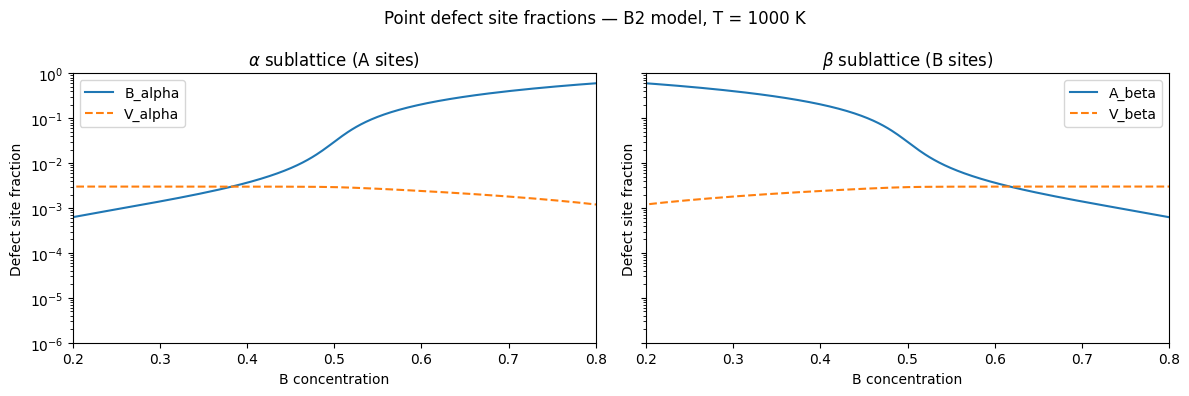

In [5]:
T = 1000  # K
dmus = np.linspace(-1.5, 1.5, 500)

# Total B concentration at each chemical potential
c_total = ab_defected.concentration(T, dmus)

def site_fractions(sublattice, T, dmus):
    """Return defect site fractions x_i^l (Eq. 3) for each defect on the sublattice."""
    zes = sublattice._get_zes(T, dmus)  # shape (n_defects, n_dmu)
    denom = 1 + zes.sum(axis=0)
    return {d.name: ze / denom for d, ze in zip(sublattice.defects, zes)}

fracs_alpha = site_fractions(alpha_sublattice, T, dmus)
fracs_beta  = site_fractions(beta_sublattice,  T, dmus)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

linestyles = ['-', '--']
for ax, fracs, title in zip(
    axes,
    [fracs_alpha, fracs_beta],
    [r'$\alpha$ sublattice (A sites)', r'$\beta$ sublattice (B sites)'],
):
    for (name, frac), ls in zip(fracs.items(), linestyles):
        ax.semilogy(c_total, frac, ls=ls, label=name)
    ax.set_xlabel('B concentration')
    ax.set_ylabel('Defect site fraction')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0.2, 0.8)
    ax.set_ylim(1e-6, 1)

fig.suptitle(f'Point defect site fractions — B2 model, T = {T} K')
plt.tight_layout()
plt.show()

On the B-rich side ($c > 0.5$), B$_\alpha$ antisites dominate; on the A-rich side ($c < 0.5$),
A$_\beta$ antisites dominate.  The site competition captured by the denominator in Eq. (3) ensures
that defect fractions remain physically bounded even at large off-stoichiometry.

### Phase Diagram

The B2 phase now appears with **finite solubility** determined self-consistently by the point
defect model, rather than as a vertical line at $c = 0.5$.

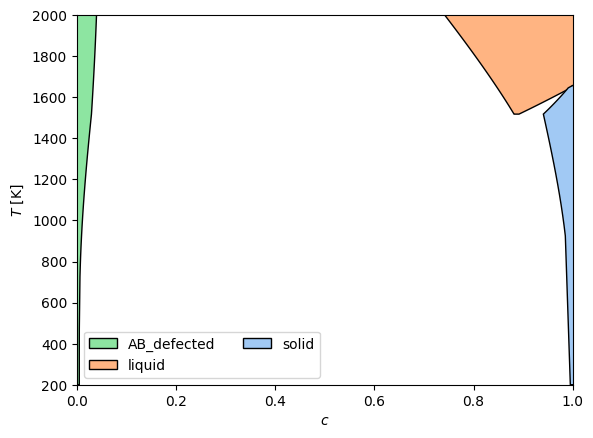

In [6]:
# Terminal solid solutions
solid_a = LinePhase('A',    fixed_concentration=0, line_energy=-2.0, line_entropy=1.0*kB)
solid_b = LinePhase('B',    fixed_concentration=1, line_energy=-3.0, line_entropy=1.5*kB)
solid   = IdealSolution('solid', solid_a, solid_b)

# Liquid
liquid_a = LinePhase('A(l)', fixed_concentration=0, line_energy=-1.9, line_entropy=2.5*kB)
liquid_b = LinePhase('B(l)', fixed_concentration=1, line_energy=-2.9, line_entropy=2.2*kB)
liquid   = IdealSolution('liquid', liquid_a, liquid_b)

df = calc_phase_diagram(
    [solid, liquid, ab_defected],
    Ts=np.linspace(200, 2000, 200),
    mu=200,
)
plot_phase_diagram(df, tielines=True)

## Parametrisation: Endmember Energies vs. Point Defect Energies

The table below shows how to convert between the two conventions for a B2 phase where the
$\alpha$-sites host A and the $\beta$-sites host B:

| CEF endmember | Composition | `PointDefectedPhase` parameters |
|--------------|------------|--------------------------------|
| A:A (all A)   | $c=0$   | $E_\text{host} + E_{A_\beta}/\eta_\beta$ |
| A:B (stoich.) | $c=0.5$ | $E_\text{host}$ |
| B:B (all B)   | $c=1$   | $E_\text{host} + E_{B_\alpha}/\eta_\alpha$ |

This makes it straightforward to switch between DFT defect supercell results (natural input for
`PointDefectedPhase`) and CEF databases that list endmember energies.

To verify: the semi-grand potential of the defected phase at the pure-A limit ($\Delta\mu \to -\infty$)
should equal the endmember energy of the A:A configuration.

In [7]:
T_check = 0.01  # near 0 K to suppress entropy

# Defected phase at very negative dmu (A-rich limit)
phi_A_limit = ab_defected.semigrand_potential(T_check, dmu=-5.0)
c_A_limit   = ab_defected.concentration(T_check, dmu=-5.0)

# CEF endmember A:A predicted from the table above
E_host   = host.line_energy
E_A_beta = A_beta.excess_energy
eta_beta = beta_sublattice.sublattice_fraction
E_AA_endmember = E_host + E_A_beta / eta_beta

print(f'c at dmu=-5: {c_A_limit:.6f}  (expected ~0)')
print(f'phi(T~0, dmu=-5) = {phi_A_limit:.4f} eV')
print(f'phi_host - c*dmu = {E_AA_endmember - c_A_limit*(-5.0):.4f} eV  (from CEF endmember)')

c at dmu=-5: nan  (expected ~0)
phi(T~0, dmu=-5) = -inf eV
phi_host - c*dmu = nan eV  (from CEF endmember)


/home/runner/work/landau/landau/landau/phases/__init__.py:775: RuntimeWarning: overflow encountered in exp
  return np.array([np.exp(-(fe - ne * dmu) / kB / T) for fe, ne in zip(fes, nes)])
/home/runner/work/landau/landau/landau/phases/__init__.py:786: RuntimeWarning: invalid value encountered in scalar divide
  return eta * sum(ne * ze for ne, ze in zip(nes, zes)) / (1 + zes.sum(axis=0))


## Further Reading

- **Dissertation §11.1** (Poul 2024): Full derivation of Eqs. (1)–(4) from the semi-grand canonical partition function.
- **Khatri, Koju & Mishin (2024)** *J. Phase Equilib. Diffus.* 45, 375–393 — law-of-mass-action / Kröger–Vink approach; the semi-grand potential model above is equivalent at the ideal-mixing level.
- **Westwood et al. (2015)** *Comput. Phys. Commun.* 196, 145–151 — `pycpd` Python module implementing the dilute (low-temperature) limit.